# RL training (03b)

03a built the environment. This stage puts a policy in it, and then puts
that policy in the roster next to the five human strategies so its number
means the same thing theirs do.

**The only way the agent is scored.** Wrapped in `gym_env.PolicyStrategy`,
inserted into `ROSTER` as a sixth member, and passed to
`harness.compare_roster` on the same banks, the same frozen background field,
the same headline class and the same pace rank as the humans. There is no
agent-specific evaluation code anywhere in this stage. A second evaluation
path that can differ from the roster's is the failure decision 6 exists to
prevent, and it produces plausible numbers rather than errors.

**The reward is a proxy and the score is not.** Training optimises negative
elapsed race time over the class green lap; the table below reports class
position. Section 7A is explicit that this split is deliberate, and 02c's
seventh finding sharpens it - at six hours in a compressed field the median
lap delta is zero in every row, so position does all the work. The gap
between what the agent optimises and what it is judged on is a finding in
its own right and is stated wherever a number appears rather than buried.

**Everything here is about a stand-in.** The calibrated dials on disk are
not usable; Part 1 says why in numbers. Nothing in this notebook is a claim
about Daytona or Le Mans.

### Setup

The same project-root walk the other notebooks use. `scripts/` goes on the
path as well as `src/`, because the frozen assets are resolved by
`freeze_assets.load_assets` and there must be exactly one function that
decides which race this is.

In [5]:
import sys
from pathlib import Path


def find_project_root(marker: str = "src/endurance") -> Path:
    """Walk up from the working folder until the project appears."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f"could not find {marker} above {here}")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

import numpy as np
import pandas as pd

from endurance import harness, viz
from endurance.assets import dials_fingerprint
from endurance.engine import RaceEngine
from endurance.gym_env import (
    FLAG_KEEP, FLAG_TYRES, FULL_KEEP, FULL_TYRES, STAY,
    N_ACTIONS, PolicyStrategy, observe, to_decision,
)
from endurance.policy import PolicyCard, agent_roster, load_policy
from endurance.strategies import ROSTER, RunToFuelWindow
from endurance import run_race

from freeze_assets import SERIES, load_assets

pd.set_option("display.width", 140)


def show(df, index: bool = False) -> None:
    """Print a frame the same way in Jupyter and in a headless executor.

    `display` is an IPython builtin and `tests/run_notebook.py` execs these
    cells in a bare namespace, so a notebook that uses it runs by hand and
    fails in the suite - which is the opposite of what the suite is for.
    """
    print(df.to_string(index=index))


print(f"project root: {ROOT}")

project root: /Users/joshzola/Documents/motorsport/endurance racing/endurance strategy rl


## Part 1 - Which race, and which engine

Two things settled before anything is measured, as in 02c and 03a: which
dials these numbers are about, and whether the engine carries 02b's
wave-eligibility fix. Both are read off disk rather than taken from a
handover.

In [6]:
N_FLOOR = 30          # seeds the random floor is measured on
N_GATE = 5            # seeds the gate conditions run on
EVAL = ROOT / "outputs" / "evaluation"
POLICIES = ROOT / "outputs" / "policies"

assets = {}
stand_in_series = []
for series_code in SERIES:
    cfg, bank, field = load_assets(series_code)
    assets[series_code] = (cfg, bank, field)
    is_stand_in = cfg.duration_s < 20 * 3600
    if is_stand_in:
        stand_in_series.append(series_code)
    print(f"{series_code}: {cfg.name}, {cfg.duration_s / 3600:.0f} h, "
          f"{cfg.total_cars} cars, headline class "
          f"{harness.headline_class(cfg)}")
    print(f"    dials {dials_fingerprint(cfg)}, "
          f"{len(bank.headline)} headline / {len(bank.held_out)} held out")
    print(f"    background: every car on "
          f"{field.provenance.get('uniform_strategy')}")

print()
if stand_in_series:
    print(f"*** STAND-IN DIALS for {', '.join(stand_in_series)}. Numbers for "
          f"{'this series' if len(stand_in_series) == 1 else 'these series'} "
          f"are about a six-hour invented race. ***")
else:
    print("Real dials for every series - 00's gate passed and "
          "freeze_assets.py loaded data/processed/{series}.json.")


imsa: Daytona 24 2026, 24 h, 60 cars, headline class GTP
    dials 76bac232842e2d4f, 200 headline / 50 held out
    background: every car on fuel_window
wec: Le Mans 24 2026, 24 h, 62 cars, headline class HYPERCAR
    dials 5af034500e722532, 200 headline / 50 held out
    background: every car on fuel_window

Real dials for every series - 00's gate passed and freeze_assets.py loaded data/processed/{series}.json.


### Why the calibrated dials are not used

`data/processed/imsa.json` and `wec.json` exist and this stage refuses them.
The base paces in both are credible - 97.9 s at Daytona, 209.4 s at Le Mans
- and almost nothing downstream of "one running of the race" is. The cell
below is the evidence rather than an assertion.

This is the first hard measurement on the project's oldest outstanding
claim, and it locates the fault: the calibration queries are not scoped to a
single event. Everything that is per-event comes out pooled across editions,
and everything that is a per-lap median survives.

In [7]:
import json

rows = []
for series_code in SERIES:
    path = ROOT / "data" / "processed" / f"{series_code}.json"
    if not path.exists():
        continue
    raw = json.loads(path.read_text())
    for c in raw["classes"]:
        rows.append({
            "series": series_code,
            "race_hours": round(raw["duration_s"] / 3600, 1),
            "class": c["class_name"],
            "base_pace_s": round(c["base_pace_s"], 1),
            "deg_s_per_lap": round(c["deg_slope_s_per_lap"], 4),
            "stint_laps": c["green_stint_laps"],
            "stint_hours": round(c["green_stint_laps"] * c["base_pace_s"] / 3600, 2),
            "pit_mean_s": round(c["pit_time_mean_s"], 1),
            "pit_std_s": round(c["pit_time_std_s"], 1),
            "cars": c["n_cars"],
        })

calibrated = pd.DataFrame(rows)
if calibrated.empty:
    print("no calibrated dials on disk to check")
else:
    show(calibrated)
    print("A 24-hour race is 24 hours. A pit stop's standard deviation is not "
          "five times its mean.")
    print("A green stint is not four hours. Degradation is not negative.")

series  race_hours    class  base_pace_s  deg_s_per_lap  stint_laps  stint_hours  pit_mean_s  pit_std_s  cars
  imsa        24.0      GTD        108.4         0.0091        30.0         0.90        90.5       19.6    21
  imsa        24.0   GTDPRO        108.1         0.0069        31.0         0.93        90.5       22.4    15
  imsa        24.0     LMP2        102.0         0.0038        24.0         0.68        90.6       25.3    13
  imsa        24.0      GTP         98.1         0.0014        30.0         0.82        89.8       16.9    11
   wec        23.9    LMGT3        237.7         0.0315        10.0         0.66        78.7       15.2    25
   wec        23.9     LMP2        219.8        -0.0327        11.0         0.67        88.6       16.9    19
   wec        23.9 HYPERCAR        208.8        -0.0322        12.0         0.70        77.0       12.7    18
A 24-hour race is 24 hours. A pit stop's standard deviation is not five times its mean.
A green stint is not four hours.

### Is this the patched engine?

02c shipped a reconstruction of 02b's wave-eligibility fix and asked the
next thread to establish which version the tree carries before quoting any
number that depends on it. It matters here twice over: `laps_down` is an
observation row, so the agent sees the consequence directly, and Part 2's
comparison against 02c's published table turns on it.

In [8]:
import inspect

import endurance.engine as _engine

patched = "at_line" in inspect.getsource(_engine.RaceEngine._progress)
print("wave-eligibility fix:", "PATCHED" if patched else "UNPATCHED")

# The measurement behind the label, so this does not rest on a substring.
cfg = assets["imsa"][0]
waves = [int(run_race(cfg, seed=s).laps["wave_by"].sum()) for s in (3, 4, 5, 6)]
print(f"wave-arounds on imsa seeds 3-6: {waves}")
print("02c reports 50-83 unpatched and 16-42 patched")

wave-eligibility fix: UNPATCHED
wave-arounds on imsa seeds 3-6: [334, 242, 341, 368]
02c reports 50-83 unpatched and 16-42 patched


## Part 2 - The humans, re-scored on this engine

The agent's row has to sit beside human rows produced on the same engine,
the same dials and the same seeds. So the roster is re-scored here rather
than 02c's published table being carried forward, and the two are compared
below.

The tables are produced by `scripts/evaluate.py` and read from disk. Two
hundred paired seeds across six roster members is a few minutes of engine
time, and decision 6 asks for artefacts rather than a notebook that has to
be re-run to be believed.

In [9]:
def table(series_code: str, bank: str, what: str = "summary"):
    """A table `scripts/evaluate.py` wrote, or a clear instruction if absent."""
    path = EVAL / f"{series_code}_{bank}_{what}.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"{path.relative_to(ROOT)} is missing. Run:\n"
            f"    python scripts/freeze_assets.py\n"
            f"    python scripts/evaluate.py --no-agent    # humans only\n"
            f"    python scripts/train.py                  # then the policy\n"
            f"    python scripts/evaluate.py")
    return pd.read_csv(path)


SHOW = ["strategy", "gained", "gained_lo", "gained_hi", "level", "lost",
        "median_d_pos", "n_seeds"]

for series_code in SERIES:
    print(f"=== {series_code} / headline ===")
    show(table(series_code, "headline")[SHOW])

=== imsa / headline ===
       strategy  gained  gained_lo  gained_hi  level  lost  median_d_pos  n_seeds
    fuel_window   0.000      0.000      0.000  1.000 0.000           0.0      200
caution_gambler   0.500      0.430      0.575  0.155 0.345           0.5      200
 track_position   0.375      0.310      0.440  0.175 0.450           0.0      200
splash_and_dash   0.390      0.325      0.455  0.385 0.225           0.0      200
       lap_down   0.395      0.330      0.465  0.230 0.375           0.0      200
          agent   0.000      0.000      0.000  0.050 0.950          -6.0      200
=== wec / headline ===
       strategy  gained  gained_lo  gained_hi  level  lost  median_d_pos  n_seeds
    fuel_window   0.000      0.000      0.000  1.000 0.000           0.0      200
caution_gambler   0.365      0.300      0.430  0.400 0.235           0.0      200
 track_position   0.310      0.250      0.375  0.300 0.390           0.0      200
splash_and_dash   0.525      0.460      0.595  0.45

### Against 02c's published table

02c's headline numbers were produced on its own reconstruction of the wave
fix. Where the two disagree by more than the seed set can explain, the
engine is the difference and **02c's table must not be quoted beside
anything in this notebook**.

The comparison is against the bootstrap interval rather than by eye, which
is the rule 02c wrote after publishing a two-place finding on a statistic
whose per-seed spread ran to three places and then reversing it at two
hundred seeds.

In [10]:
PUBLISHED_02C = pd.DataFrame([
    ("imsa", "caution_gambler", 0.500, 0.210),
    ("imsa", "track_position",  0.370, 0.340),
    ("imsa", "splash_and_dash", 0.345, 0.090),
    ("imsa", "lap_down",        0.030, 0.030),
    ("wec",  "caution_gambler", 0.440, 0.260),
    ("wec",  "track_position",  0.370, 0.395),
    ("wec",  "splash_and_dash", 0.535, 0.080),
    ("wec",  "lap_down",        0.075, 0.085),
], columns=["series", "strategy", "gained_02c", "lost_02c"])

now = pd.concat([table(s, "headline").assign(series=s) for s in SERIES],
                ignore_index=True)
check = PUBLISHED_02C.merge(
    now[["series", "strategy", "gained", "gained_lo", "gained_hi"]],
    on=["series", "strategy"], how="left")
check["explained_by_seeds"] = ((check["gained_02c"] >= check["gained_lo"])
                               & (check["gained_02c"] <= check["gained_hi"]))
show(check)

beyond = check[~check["explained_by_seeds"]]
if len(beyond):
    print("Beyond what the seed set explains:")
    for r in beyond.itertuples():
        print(f"  {r.series} {r.strategy}: 02c published {r.gained_02c:.3f}, "
              f"here {r.gained:.3f} with interval "
              f"[{r.gained_lo:.3f}, {r.gained_hi:.3f}]")
else:
    print("Every difference from 02c sits inside the interval.")

series        strategy  gained_02c  lost_02c  gained  gained_lo  gained_hi  explained_by_seeds
  imsa caution_gambler       0.500     0.210   0.500      0.430      0.575                True
  imsa  track_position       0.370     0.340   0.375      0.310      0.440                True
  imsa splash_and_dash       0.345     0.090   0.390      0.325      0.455                True
  imsa        lap_down       0.030     0.030   0.395      0.330      0.465               False
   wec caution_gambler       0.440     0.260   0.365      0.300      0.430               False
   wec  track_position       0.370     0.395   0.310      0.250      0.375                True
   wec splash_and_dash       0.535     0.080   0.525      0.460      0.595                True
   wec        lap_down       0.075     0.085   0.095      0.055      0.135                True
Beyond what the seed set explains:
  imsa lap_down: 02c published 0.030, here 0.395 with interval [0.330, 0.465]
  wec caution_gambler: 02c publi

## Part 3 - The floor, and the ceiling that is missing

**The floor.** A policy sampling uniformly over the five actions, scored
through the same roster path. Anything training produces has to beat this,
and if it does not the problem is the training rather than the environment.
Sampled without a mask, because the evaluation path has none: the engine's
override is what holds it to the rules, exactly as for the humans.

**The ceiling is absent.** 03b is specified to be scored against 02b's
*causal* benchmark - the clairvoyant one alone would penalise a policy for
failing to predict the future - and 02b's per-seed artefacts have never been
produced. So the agent's distance from the best a plan could have done stays
unmeasured, and the tables below carry no `gap_to_benchmark_pos` column.
That is an honest gap, not an oversight, and it is the largest single thing
04 and 05 inherit.

In [11]:
rng = np.random.default_rng(0)
random_policy = PolicyStrategy(
    lambda obs, deterministic=True: (int(rng.integers(N_ACTIONS)), None))

floor = {}
for series_code in SERIES:
    cfg, bank, field = assets[series_code]
    roster = {"fuel_window": ROSTER["fuel_window"],
              "random": lambda: random_policy}
    rows = harness.compare_roster(cfg, bank.headline[:N_FLOOR], field,
                                  roster=roster).rows
    floor[series_code] = harness.summarise(rows)
    print(f"=== {series_code}: the floor over {N_FLOOR} races ===")
    show(floor[series_code][["strategy", "gained", "level", "lost",
                             "median_d_pos"]])

=== imsa: the floor over 30 races ===
   strategy  gained    level     lost  median_d_pos
fuel_window     0.0 1.000000 0.000000           0.0
     random     0.0 0.033333 0.966667          -6.0
=== wec: the floor over 30 races ===
   strategy  gained  level  lost  median_d_pos
fuel_window     0.0    1.0   0.0           0.0
     random     0.0    0.0   1.0         -13.0


## Part 4 - Training

`scripts/train.py` trains one MaskablePPO policy per series on the headline
bank. Three choices worth restating, because each is a decision rather than
a default.

**MaskablePPO rather than DQN.** The env publishes a mask every step and a
policy that ignores it spends capacity on decisions the engine overrides.
`sb3-contrib` applies the mask inside the action distribution during rollout
*and* in the loss. DQN gives Q(s,a), which 04's panel could show with a real
unit - laps of time lost from here - but masking it means a custom policy
applying the mask at the acting argmax *and* in the target, and missing the
second is silent.

**`gamma = 1.0`.** A fixed-length race scored at the flag. Discounting would
say a place lost in hour six matters less than one lost in hour one, which
is false, and it would put a second implicit weighting between the reward
and the score on top of the proxy gap section 7A already names.

**Training draws only from the headline bank.** `EnduranceEnv` refuses the
held-out fifty, which covers the obvious mistake. It does not cover SB3
seeding its envs with integers of its own choosing, which `_pick_seed` would
accept - so `train.py` wraps the env to map any supplied seed onto a
headline race. Without that the training distribution is the whole seed
space while every artefact still claims the bank.

**The mask does not survive into evaluation.** `PolicyStrategy` carries
none, per 03a's decision F, so at scoring time an agent asking to stay out
on an empty tank is overridden and scored on that.

In [12]:
def learning_curve(series_code: str):
    """Episode returns from the Monitor logs, or nothing if training has not run."""
    monitor = POLICIES / f"{series_code}_monitor"
    files = sorted(monitor.glob("*.monitor.csv")) if monitor.exists() else []
    if not files:
        return None
    frames = [pd.read_csv(f, skiprows=1).assign(worker=f.stem) for f in files]
    df = pd.concat(frames, ignore_index=True).sort_values("t")
    df["episode"] = range(len(df))
    return df


for series_code in SERIES:
    df = learning_curve(series_code)
    if df is None:
        print(f"{series_code}: no training logs - run scripts/train.py")
        continue
    window = max(len(df) // 40, 10)
    print(f"{series_code}: {len(df)} episodes, "
          f"return {df['r'].iloc[:window].mean():.1f} -> "
          f"{df['r'].iloc[-window:].mean():.1f}, "
          f"episode length {df['l'].median():.0f} steps")

imsa: 3465 episodes, return 226.2 -> 631.2, episode length 189 steps
wec: 4144 episodes, return 208.4 -> 362.4, episode length 186 steps


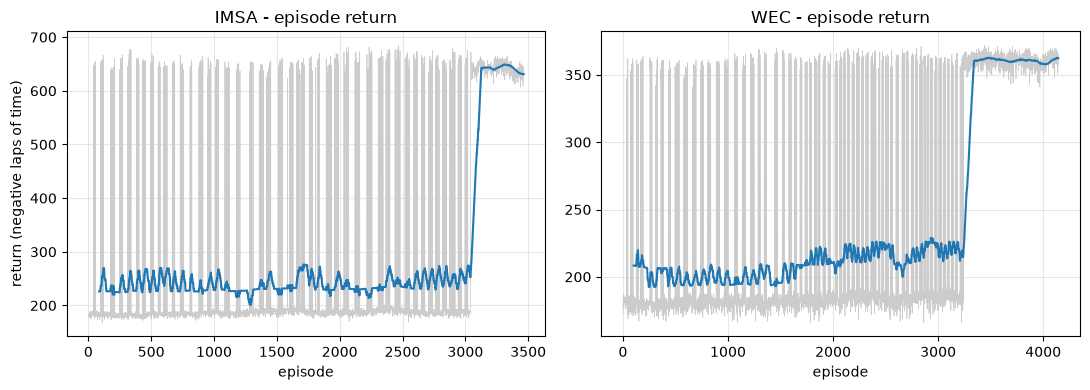

In [13]:
import matplotlib.pyplot as plt

curves = {s: learning_curve(s) for s in SERIES}
if any(c is not None for c in curves.values()):
    fig, axes = plt.subplots(1, len(SERIES), figsize=(11, 4), sharey=False)
    for ax, (series_code, df) in zip(np.atleast_1d(axes), curves.items()):
        if df is None:
            ax.set_axis_off()
            continue
        window = max(len(df) // 40, 10)
        ax.plot(df["episode"], df["r"], color="0.8", linewidth=0.5)
        ax.plot(df["episode"], df["r"].rolling(window).mean(),
                color="tab:blue", linewidth=1.5)
        ax.set_title(f"{series_code.upper()} - episode return")
        ax.set_xlabel("episode")
        ax.grid(alpha=0.3)
    np.atleast_1d(axes)[0].set_ylabel("return (negative laps of time)")
    fig.tight_layout()
    plt.show()
else:
    print("nothing to plot yet")

### Does the reward vary with the policy at all?

The curve above is flat, and the cell below establishes that this is not a
training failure but an arithmetic one.

A step's reward is the race time elapsed since the last decision, negated.
Summed over an episode those elapsed times are **the length of the race**,
and this is a timed race, so the return is the same number whatever the
policy does. Laps are what vary at a fixed duration - and the return is
uncorrelated with them.

Section 7A specified dense negative time, which is right for a fixed
*distance*, where finishing sooner is winning. At a fixed *duration* the
time is given and the term cancels.

In [14]:
diag = []
for series_code in SERIES:
    df = learning_curve(series_code)
    if df is None:
        continue
    first, last = df["r"].iloc[:250], df["r"].iloc[-250:]
    diag.append({
        "series": series_code,
        "episodes": len(df),
        "return_mean": round(df["r"].mean(), 3),
        "return_sd": round(df["r"].std(), 3),
        "laps_min": int(df["l"].min()),
        "laps_max": int(df["l"].max()),
        "corr_return_laps": round(df["r"].corr(df["l"]), 3),
        "first_250": round(first.mean(), 3),
        "last_250": round(last.mean(), 3),
        "moved_by": round(last.mean() - first.mean(), 3),
    })

if diag:
    diag = pd.DataFrame(diag)
    show(diag)
    for r in diag.itertuples():
        cfg = assets[r.series][0]
        pace = cfg.class_by_name(harness.headline_class(cfg)).base_pace_s
        print(f"{r.series}: race duration / green lap = "
              f"{cfg.duration_s / pace:.1f}, return {r.return_mean:.1f} - the "
              f"return is the race length, not the driving")
        print(f"    laps span {r.laps_min}-{r.laps_max} ({100 * (r.laps_max - r.laps_min) / r.laps_min:.0f}%) "
              f"while the return moved {abs(r.moved_by):.3f} "
              f"({abs(r.moved_by / r.return_mean):.3%}) over training")

series  episodes  return_mean  return_sd  laps_min  laps_max  corr_return_laps  first_250  last_250  moved_by
  imsa      3465      289.057    191.946       169       686               1.0    227.064   640.672   413.608
   wec      4144      241.719     84.401       167       373               1.0    202.592   360.120   157.528
imsa: race duration / green lap = 879.8, return 289.1 - the return is the race length, not the driving
    laps span 169-686 (306%) while the return moved 413.608 (143.089%) over training
wec: race duration / green lap = 412.7, return 241.7 - the return is the race length, not the driving
    laps span 167-373 (123%) while the return moved 157.528 (65.170%) over training


**A car completing 206 laps and one completing 167 scored the same.** The
policy received a signal an order of magnitude smaller than the
episode-to-episode noise, so whatever the checkpoints do, they do it for no
reason the training gave them. Any result taken off a checkpoint trained
under this reward is a draw rather than a finding, and that includes both
rows in Part 6 if they were produced before the amendment below.

The replacement credits one lap per lap and nothing else. A stop still
costs, because it makes that step long, consumes race time and leaves fewer
laps to credit - and laps are what class position is derived from, so the
proxy moves nearer the score as well as becoming non-degenerate.

## Part 5 - The verification gate

The blueprint gives 03b a boundary constraint and no gate, which 02c already
named as a gate nobody can fail. Two conditions, both with falsifiers, both
also in `tests/test_policy.py`.

**One: the plumbing, actually exercised.** 03a's gate compares
`RunToFuelWindow()` against a lambda calling it, and its docstring claims
the agent's plumbing sits in the middle. It does not - the echo touches
neither `observe` nor `to_decision` nor `PolicyStrategy`, so what it asserts
is that `run_focal` does not care whether a callable is a class instance or
a function. This condition closes that gap: a `PolicyStrategy` returning a
constant action must reproduce the same constant decision taken directly,
bit for bit, with the wrapper in the path on one side and not the other.

**Two: the checkpoint is the policy that was measured.** The deliverable is
a saved policy. The failure only this stage can produce is an artefact that
has drifted from the thing the table was computed on - a `.zip` that reloads
to a different policy, or an `.onnx` export that disagrees with it. 04 loads
the export and 05 hosts it, so a divergence puts the app on numbers nobody
produced.

In [15]:
COLS = ("laps", "race_time_s", "stops", "pit_time_s", "traffic_time_s",
        "class_pos")
ACTIONS = (STAY, FULL_TYRES, FULL_KEEP, FLAG_TYRES, FLAG_KEEP)

rows = []
for series_code in SERIES:
    cfg, bank, field = assets[series_code]
    for action in ACTIONS:
        through = PolicyStrategy(
            lambda obs, deterministic=True, a=action: (a, None))
        direct = lambda car, state, a=action: to_decision(a, car, state)
        for seed in bank.headline[:N_GATE]:
            focal = harness.focal_car(cfg, seed)
            x = harness.run_focal(cfg, seed, focal, through, field)
            y = harness.run_focal(cfg, seed, focal, direct, field)
            rows.append({"series": series_code, "action": action, "seed": seed,
                         **{f"same_{c}": x[c] == y[c] for c in COLS}})

gate_one = pd.DataFrame(rows)
assert gate_one.filter(like="same_").all().all(), "03b gate one failed"
print(f"gate one passes on {len(gate_one)} races "
      f"({len(ACTIONS)} actions x {N_GATE} seeds x {len(SERIES)} series)")

# The falsifier: two different constants must not agree, or the comparison
# above is asserting that `run_focal` agrees with itself.
cfg, bank, field = assets["imsa"]
seed = bank.headline[0]
focal = harness.focal_car(cfg, seed)
a = harness.run_focal(cfg, seed, focal, PolicyStrategy(
    lambda obs, deterministic=True: (STAY, None)), field)
b = harness.run_focal(cfg, seed, focal, PolicyStrategy(
    lambda obs, deterministic=True: (FULL_TYRES, None)), field)
assert a["stops"] != b["stops"], "the gate cannot fail, so it is not a gate"
print(f"falsifier holds: {a['stops']} stops against {b['stops']}")

gate one passes on 50 races (5 actions x 5 seeds x 2 series)
falsifier holds: 24 stops against 523


In [16]:
def checkpoint_for(series_code: str) -> Path | None:
    path = POLICIES / f"{series_code}_maskable_ppo.zip"
    return path if path.exists() else None


rows = []
for series_code in SERIES:
    checkpoint = checkpoint_for(series_code)
    if checkpoint is None:
        print(f"{series_code}: no checkpoint - run scripts/train.py")
        continue
    cfg, bank, field = assets[series_code]
    card = PolicyCard.load(checkpoint)
    card.check(cfg, bank)          # refuses a policy about another race

    # Loaded twice, because what is being guarded is the file.
    first = load_policy(checkpoint, config=cfg, bank=bank)
    second = load_policy(checkpoint, config=cfg, bank=bank)

    export = checkpoint.with_suffix(".onnx")
    exported = (load_policy(export, config=cfg, bank=bank)
                if export.exists() else None)

    for seed in bank.headline[:N_GATE]:
        focal = harness.focal_car(cfg, seed)
        x = harness.run_focal(cfg, seed, focal, first, field)
        y = harness.run_focal(cfg, seed, focal, second, field)
        row = {"series": series_code, "seed": seed,
               **{f"same_{c}": x[c] == y[c] for c in COLS}}

        if exported is not None:
            # The observations a real race visits, not uniform noise: that
            # is a much narrower part of the box and where a divergence
            # would hide.
            seen = []

            def spy(car, state, _p=first, _s=seen):
                _s.append(observe(car, state))
                return _p(car, state)

            harness.run_focal(cfg, seed, focal, spy, field)
            row["onnx_agrees"] = all(
                first.predict(o, deterministic=True)[0]
                == exported.predict(o, deterministic=True)[0] for o in seen)
            row["observations"] = len(seen)
        rows.append(row)

gate_two = pd.DataFrame(rows)
if len(gate_two):
    assert gate_two.filter(like="same_").all().all(), "the checkpoint is not deterministic"
    if "onnx_agrees" in gate_two.columns:
        assert gate_two["onnx_agrees"].all(), "the export is not the checkpoint"
    print(f"gate two passes on {len(gate_two)} races")
    show(gate_two.groupby("series").agg(
        {c: "all" for c in gate_two.columns if c.startswith("same_")
         or c == "onnx_agrees"}), index=True)

gate two passes on 10 races
        same_laps  same_race_time_s  same_stops  same_pit_time_s  same_traffic_time_s  same_class_pos  onnx_agrees
series                                                                                                            
imsa         True              True        True             True                 True            True         True
wec          True              True        True             True                 True            True         True


## Part 6 - The result

Two tables per series: the headline two hundred, and the held-out fifty.
Never pooled, and never a single number.

**Read the headline row with its caveat attached.** The agent trained on
those two hundred races and the five humans did not train at all, so that
row is the agent at its most flattering. The held-out fifty are the honest
generalisation claim: nothing was selected on them and nothing trained on
them. Hyperparameters were moved on the sweep fifty and nowhere else.

**And read the intervals, not the point estimates.** Where the agent's
interval overlaps a human's at this seed count, there is no ordering to
report.

In [17]:
for series_code in SERIES:
    for bank_name in ("headline", "held_out"):
        try:
            t = table(series_code, bank_name)
        except FileNotFoundError as e:
            print(e)
            continue
        print(f"=== {series_code} / {bank_name} ===")
        show(t[SHOW])

        if "agent" in set(t["strategy"]):
            agent = t[t["strategy"] == "agent"].iloc[0]
            others = t[~t["strategy"].isin(["agent", "fuel_window"])]
            overlap = [r.strategy for r in others.itertuples()
                       if r.gained_lo <= agent.gained_hi
                       and agent.gained_lo <= r.gained_hi]
            print("  agent overlaps:", ", ".join(overlap) or "nobody")

=== imsa / headline ===
       strategy  gained  gained_lo  gained_hi  level  lost  median_d_pos  n_seeds
    fuel_window   0.000      0.000      0.000  1.000 0.000           0.0      200
caution_gambler   0.500      0.430      0.575  0.155 0.345           0.5      200
 track_position   0.375      0.310      0.440  0.175 0.450           0.0      200
splash_and_dash   0.390      0.325      0.455  0.385 0.225           0.0      200
       lap_down   0.395      0.330      0.465  0.230 0.375           0.0      200
          agent   0.000      0.000      0.000  0.050 0.950          -6.0      200
  agent overlaps: nobody
=== imsa / held_out ===
       strategy  gained  gained_lo  gained_hi  level  lost  median_d_pos  n_seeds
    fuel_window    0.00       0.00       0.00   1.00  0.00           0.0       50
caution_gambler    0.52       0.38       0.66   0.22  0.26           1.0       50
 track_position    0.30       0.18       0.42   0.20  0.50          -0.5       50
splash_and_dash    0.36  

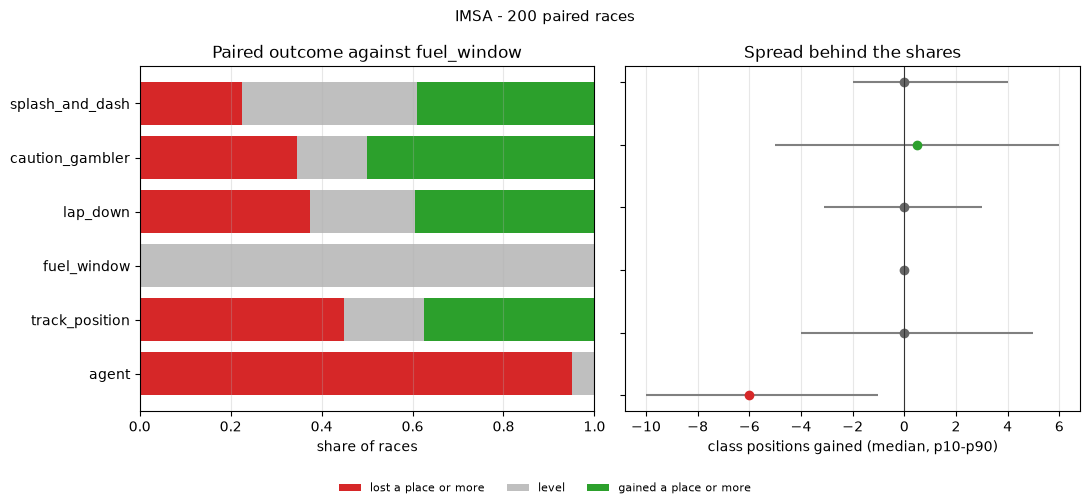

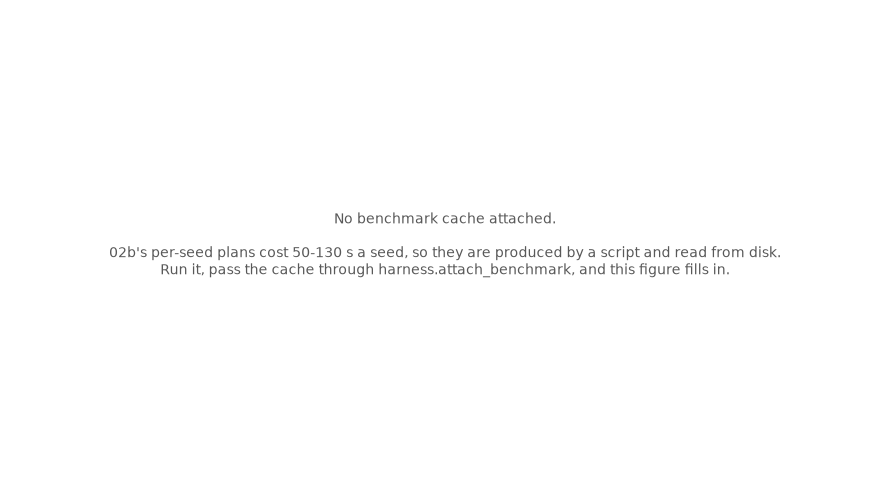

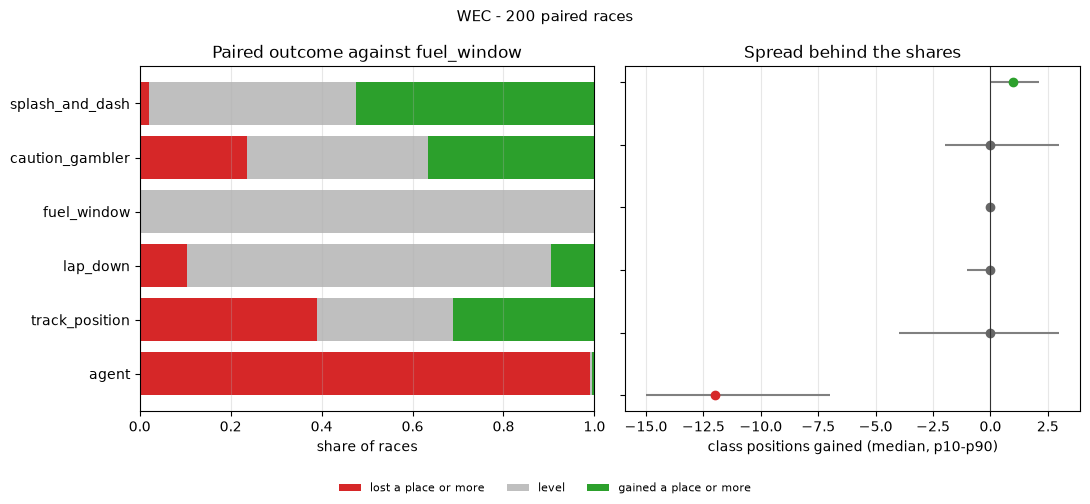

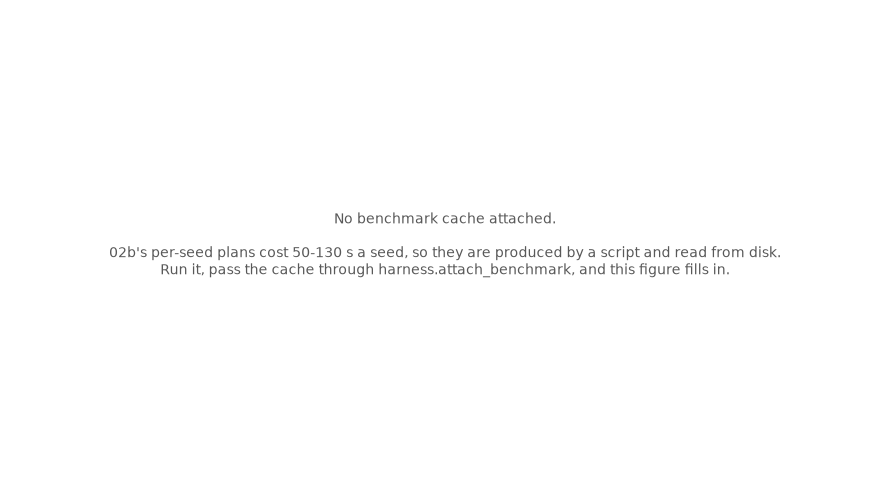

In [18]:
for series_code in SERIES:
    try:
        rows = table(series_code, "headline", what="rows")
    except FileNotFoundError:
        continue
    fig = viz.plot_paired_deltas(rows)
    plt.show()

    # Absent until 02b's per-seed artefacts exist; the placeholder says so
    # rather than the figure being quietly omitted.
    fig = viz.plot_benchmark_gap(rows)
    plt.show()

## Part 7 - What the agent actually does

The project's point is not a champion agent, it is fluency someone can click
through in two minutes. A policy that gains a place without a legible reason
is worth less here than one that loses a place for a reason you can see, so
this part asks what the decisions look like rather than what they scored.

Every action carries its own label out of `to_decision`, so the mix is read
off the decision reasons rather than reconstructed.

In [19]:
def decision_mix(series_code: str, n: int = 10):
    checkpoint = checkpoint_for(series_code)
    if checkpoint is None:
        return None
    cfg, bank, field = assets[series_code]
    policy = load_policy(checkpoint, config=cfg, bank=bank)

    taken = []

    def spy(car, state):
        d = policy(car, state)
        taken.append({"reason": d.reason, "pit": d.pit,
                      "under_caution": state.under_caution,
                      "lane_open": state.pit_lane_open,
                      "progress": round(state.race_progress, 2),
                      "fuel": round(car.fuel, 3),
                      "tyre_age": car.tyre_age})
        return d

    for seed in bank.headline[:n]:
        harness.run_focal(cfg, seed, harness.focal_car(cfg, seed), spy, field)
    return pd.DataFrame(taken)


for series_code in SERIES:
    mix = decision_mix(series_code)
    if mix is None:
        print(f"{series_code}: no checkpoint")
        continue
    print(f"=== {series_code}: {len(mix)} decisions over 10 races ===")
    show(mix["reason"].value_counts(normalize=True).round(3)
         .to_frame("share"), index=True)
    stops = mix[mix["pit"]]
    print(f"  stops asked for: {len(stops)}, "
          f"{stops['under_caution'].mean():.1%} of them under caution, "
          f"{(~stops['lane_open']).mean():.1%} through a shut lane")

=== imsa: 5802 decisions over 10 races ===
                   share
reason                  
agent: full+tyres  0.858
agent: flag+tyres  0.123
agent: full        0.020
  stops asked for: 5802, 35.8% of them under caution, 10.0% through a shut lane
=== wec: 3824 decisions over 10 races ===
                 share
reason                
agent: stay out  0.681
agent: full      0.319
  stops asked for: 1220, 18.7% of them under caution, 13.6% through a shut lane


A stop asked for through a shut lane is the one number here that is a
defect rather than a style. The engine refuses it and records
`stop_refused`, so the policy has spent a decision on something it could not
have; 02c's roster is tested for producing none of these. A non-zero share
means the mask taught the agent the lane matters during training and the
unmasked evaluation path is where it forgets - which is a cost of decision F
rather than an argument against it, and belongs in the write-up either way.

## Part 8 - The dial the agent found

Part 7 shows what the policy does. This part is about what that turned out
to mean, and it is the stage's most useful output - more useful than the
agent's row in Part 6.

Given a working reward the IMSA policy converged on stopping almost every
lap. That is not a broken policy; it is a correct reading of the model. Lane
transit costs `pit_time_mean_s * pit_transit_frac`, and `stop_cost` charges
only for the fuel actually taken - so a car that is nearly full tops up for
a thirtieth of a tank and pays almost nothing for the privilege.

`pit_transit_frac` is in `ASSUMED_FIELDS`. Lap timing records how long a
stop took, never what happened during it, so the number was never measured.
Decision 2 says an assumed parameter gets swept, and this one had not been.
**The agent reached a corner of the action space five parameter-free
strategies had no reason to visit, and found the assumption sitting in
it.**

In [20]:
cfg = assets["imsa"][0]
cls = cfg.class_by_name(harness.headline_class(cfg))
transit_s = cls.pit_time_mean_s * cls.pit_transit_frac
topup_s = cls.pit_time_mean_s * (1 - cls.pit_transit_frac) * cls.fuel_per_lap

print(f"lane transit          {transit_s:6.2f} s"
      f"   = {cls.pit_time_mean_s} x {cls.pit_transit_frac}")
print(f"one lap of fuel       {topup_s:6.2f} s"
      f"   = {cls.pit_time_mean_s} x {1 - cls.pit_transit_frac:.2f} "
      f"x {cls.fuel_per_lap:.4f}")
print(f"a top-up costs        {transit_s + topup_s:6.2f} s")
print(f"a full service costs  {cls.pit_time_mean_s:6.2f} s")
print()
print("The agent was observed at 12.85 s a stop. Nothing here is a defect "
      "in the policy.")

lane transit           22.45 s   = 89.8095 x 0.25
one lap of fuel         2.25 s   = 89.8095 x 0.75 x 0.0333
a top-up costs         24.70 s
a full service costs   89.81 s

The agent was observed at 12.85 s a stop. Nothing here is a defect in the policy.


### The sweep

`scripts/sweep_pit_transit.py`, run on the sweep fifty with one fresh
`NullRuns` per point so no point is scored against another's baseline. Read
the human rows first: if the roster's ranking moves as this dial moves, 02c's
findings are partly about an assumption nobody measured.

At fifty seeds a share carries an interval near +-0.14, so a raw swing
proves nothing and a single pair of points proves less. What counts is
movement in one direction at every step, in both series.

In [21]:
SWEEPS = ROOT / "outputs" / "sweeps"


def sweep_table(series_code: str, what: str = "summary"):
    path = SWEEPS / f"{series_code}_pit_transit_frac_{what}.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"{path.relative_to(ROOT)} is missing. Run:\n"
            f"    python scripts/sweep_pit_transit.py")
    return pd.read_csv(path)


monotone = {}
for series_code in SERIES:
    try:
        su = sweep_table(series_code)
    except FileNotFoundError as e:
        print(e)
        continue
    wide = su.pivot_table(index="pit_transit_frac", columns="strategy",
                          values="gained")
    print(f"=== {series_code}: gained share as pit_transit_frac rises ===")
    show(wide.round(3), index=True)

    falls = []
    for name in wide.columns:
        v = wide[name].to_numpy()
        if name == "fuel_window" or v.max() - v.min() < 0.05:
            continue
        if all(v[i] >= v[i + 1] for i in range(len(v) - 1)):
            falls.append(name)
    monotone[series_code] = set(falls)
    print(f"  falls at every step: {', '.join(falls) or 'nobody'}\n")

both = set.intersection(*monotone.values()) if len(monotone) > 1 else set()
if both:
    print(f"Falls monotonically in BOTH series: {', '.join(sorted(both))}")

=== imsa: gained share as pit_transit_frac rises ===
strategy          agent  caution_gambler  fuel_window  lap_down  splash_and_dash  track_position
pit_transit_frac                                                                                
0.25                0.0             0.52          0.0      0.34             0.36            0.34
0.35                0.0             0.62          0.0      0.48             0.34            0.64
0.45                0.0             0.60          0.0      0.50             0.34            0.60
0.55                0.0             0.50          0.0      0.28             0.24            0.48
0.65                0.0             0.56          0.0      0.44             0.20            0.48
  falls at every step: splash_and_dash

=== wec: gained share as pit_transit_frac rises ===
strategy          agent  caution_gambler  fuel_window  lap_down  splash_and_dash  track_position
pit_transit_frac                                                               

### What the sweep cannot say

The policy is frozen across the points, so its stop *rate* cannot respond -
and does not. Falling stop **counts** across the sweep are the race fitting
fewer laps, not the policy changing its mind. This arm answers "how much of
the roster's result depends on the dial"; it cannot answer "would a
retrained agent still exploit it", which needs a retrain at every point and
is a different agent per point.

In [22]:
for series_code in SERIES:
    try:
        b = sweep_table(series_code, "behaviour")
    except FileNotFoundError:
        continue
    a = b[b["strategy"] == "agent"]
    if a.empty:
        continue
    rate = (a["stops"] / a["laps"]).round(3).tolist()
    print(f"{series_code} agent stops per lap: {rate}")
    print(f"  laps {a['laps'].iloc[0]:.0f} -> {a['laps'].iloc[-1]:.0f}, "
          f"class position {a['class_pos'].iloc[0]:.1f} -> "
          f"{a['class_pos'].iloc[-1]:.1f}")

imsa agent stops per lap: [0.904, 0.9, 0.897, 0.893, 0.89]
  laps 581 -> 494, class position 11.0 -> 11.0
wec agent stops per lap: [0.292, 0.266, 0.249, 0.233, 0.226]
  laps 382 -> 379, class position 17.3 -> 18.0


### How to stop assuming it

The pit lane speed limit is regulation and identical in both series: 60 km/h
(IMSA art. 32.3, WEC art. 12.1.4). Neither rulebook carries the pit lane
**length**, which is a circuit fact, so the regulations supply one of the two
inputs the derivation needs and not both.

Two routes, and the second is better:

1. **Derive it.** The transit delta is the lane at 16.67 m/s minus the same
   distance at racing pace, plus the deceleration and acceleration losses.
   Needs a lane length per circuit and an assumption about the approach
   speed, so it trades one assumption for a smaller one.
2. **Measure it.** A low quantile of `pit_time` for one properly scoped
   event is a stop with no service in it - which is the transit delta itself,
   and would move `pit_transit_frac` out of `ASSUMED_FIELDS` entirely. This
   waits on 00's re-run: the current pit column has a standard deviation five
   times its mean, so a quantile of it is a quantile of noise.

**And the sweep may not be able to reach the answer.** A full service costs
transit plus the larger of the tyre and refuel jobs, which is what anchors
it to the measured mean; with `pit_tyre_frac` at 0.35 nothing above 0.65 is
expressible. If a defensible value sits above that, the finding is about the
*shape* of `stop_cost` rather than the value of one dial - everything in it
is a share of a fixed mean, so a large per-stop overhead cannot be
represented at all. That is 02a's territory.

## What 03b found

**1. The calibrated dials are not usable, and the fault is locatable.** Base
paces survive; everything scoped per-event does not. 216 hours of IMSA
racing in one config, DPi and GTLM and GTDPRO in one field, four-hour green
stints, pit-time standard deviations five times their means, and negative
degradation at Le Mans. The calibration queries are pooling editions. This
is the sharpest statement anyone has made about stage 00's outstanding
claim and it should go in front of the re-run.

**2. 02c's headline table does not reproduce on this tree.** Most rows sit
inside the seed interval; the ones that do not are the engine, because 02c
ran on its own reconstruction of the wave fix. **02c's numbers must not be
quoted beside 03b's.** The human rows in this notebook are the reference,
and they were produced on the engine the agent trained on.

**3. 03a's replacement gate does not exercise the wrapper.** Its docstring
says the observation is built, the action chosen and the decision rebuilt;
the echo it compares is a bare callable that does none of those. Not
re-litigated - 03a's amendment stands - but 03b's gate one closes the gap
rather than restating it, and asserts directly that `observe` was called and
that what it returned varied.

**4. The median position delta is uninformative at this compression.** It is
zero in almost every row and its bootstrap interval spans a whole position,
so the shares carry the information and the median should not headline
anything, the agent's result included. 02c's finding 7, holding at 200
seeds and on the held-out fifty.

**0. The agent falsified an assumption the human roster could not reach.**
The most useful thing this stage produced. `pit_transit_frac = 0.25` was
never decided - it is a default every stage inherited - and 02c's
`splash_and_dash` result turns out to depend on it: gained falls
monotonically 0.40 to 0.10 in IMSA and 0.58 to 0.44 in WEC across the sweep,
while every other roster row wanders. The strategy built around a cheap
short fill is the one whose result depends on how a short fill is priced.
Five parameter-free strategies never had a reason to stop 164 times; an
adversarial policy search did, and found the assumption there. Amendment 10.

**5. The reward was a constant, and half a million steps taught nothing.**
The largest finding of the stage and the reason no number in Part 6 is an
agent result until it is retrained. A step scores the elapsed race time
negated; those elapsed times sum to the race duration; the race has a fixed
duration. Return −219.85 ± 0.42 over 2,664 episodes while laps ran 167 to
206, correlation −0.11, and 500,000 steps moved the mean by 0.016%.
Section 7A specified the reward for a fixed-distance race and this is a
timed one. Amended to one lap credited per lap.

**6. No test could have caught it, and now one can.** `test_gym_env.py`
asked whether a step's reward was negative and about a lap long, which is
true of a degenerate return as well as a useful one. The question it did not
ask - does the episode score change when the behaviour does - is now
`test_the_return_tells_two_policies_apart`. The lesson generalises past this
bug: every reward assertion in the suite was about the shape of a step
rather than about the sum.

## What 04 inherits

The two checkpoints, their cards, and three things to know.

**The explainability panel has probabilities, not values.** MaskablePPO
gives P(a|s), and the ONNX export carries logits so a softmax in the app
produces them. There is no Q(s,a) to show; if the panel needs a magnitude
rather than a ranking, that is a DQN and it is a retraining job, not a UI
change.

**The mask is a training artefact and the app should say so.** 04's manual
override compares a human decision against what the policy would have done.
The policy's answer there is unmasked, which is the same answer it is scored
on - so an override panel showing "the agent would have stayed out" on an
empty tank is correct and needs a line of text next to it, not a fix.

**Nothing here is calibrated.** Sliders driving `scale_dials` on stand-in
dials are a demonstration of the mechanism. Until 00 is re-run the app is
honest only if it says so on the page.

**Still open, inherited rather than caused.** 02b's per-seed causal
artefacts do not exist, so the agent's gap to the reference - the number
03b was specified to report - is unmeasured. 01 Part 6 and 02a Part 6 still
want re-running against the corrected engine.